In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
df = pd.read_csv('insurance.csv')

display(df.head())

# 2. Convert Text to Numbers
# Gradient Descent matrix math requires pure numbers
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 3. Separate Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1).values # The inputs (Age, BMI, etc.)
y = df_encoded['charges'].values              # The output (Medical Costs)

# 4. Normalize the Features
# This standardizes the data so the math forms a smooth contour.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add a column of 1s to X for the bias (intercept) term in the matrix calculation
X_scaled = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# 5. Split the Data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\n--- Preprocessing Complete! ---")
print(f"Mathematical Matrix Shape for Training: {X_train.shape}")

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Preprocessing Complete! ---
Mathematical Matrix Shape for Training: (1070, 9)


Running simulation with Good Learning Rate (0.1)...
Running simulation with High Learning Rate (0.7)...

--> Exported 'Hypothesis1_Results.xlsx' to your folder!


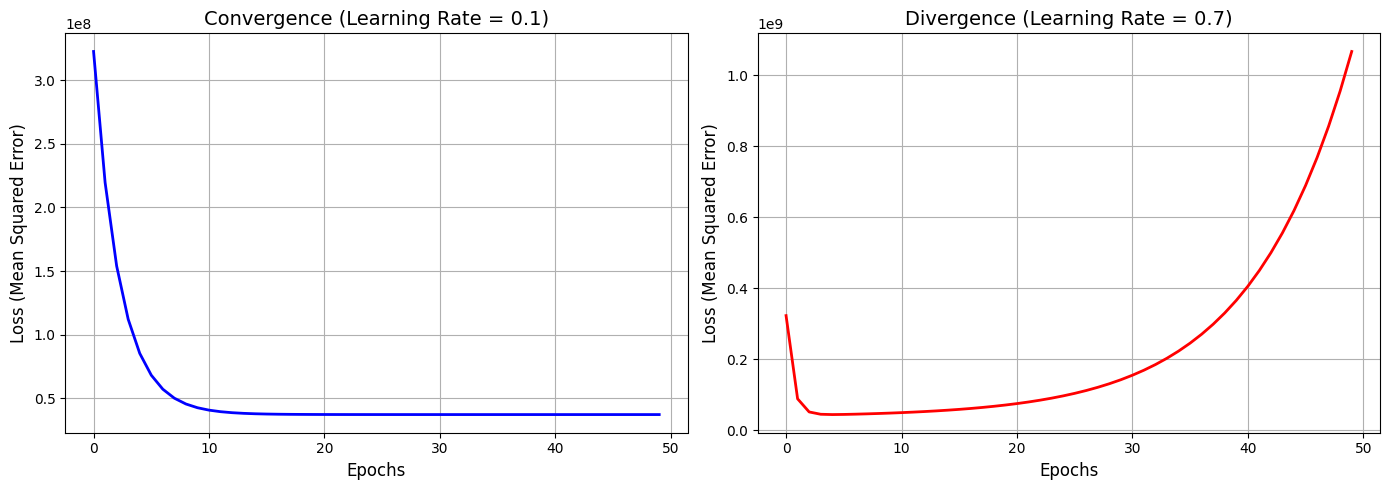

In [3]:
import matplotlib.pyplot as plt

# 1. Build the Matrix Gradient Descent Function
def batch_gradient_descent(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1]) # Start weights at 0
    loss_history = []
    metrics_for_excel = []
    
    for epoch in range(epochs):
        # MATRIX MATH: Predictions = X * weights
        predictions = X.dot(weights)
        
        # Calculate Error
        error = predictions - y
        
        # MATRIX MATH: Gradients = (2/m) * X^T * error
        gradients = (2/m) * X.T.dot(error)
        
        # Update weights using the learning rate
        weights -= learning_rate * gradients
        
        # Calculate Mean Squared Error (MSE) loss
        loss = np.mean(error**2)
        loss_history.append(loss)
        
        # Log for Excel sheet requirement
        metrics_for_excel.append({
            'Epoch': epoch + 1,
            'Learning_Rate': learning_rate,
            'Loss_Value': loss
        })
        
    return loss_history, metrics_for_excel

# 2. Run the Simulations to test Hypothesis 1
epochs = 50

# Test A: Good Learning Rate (Convergence)
print("Running simulation with Good Learning Rate (0.1)...")
loss_converge, excel_converge = batch_gradient_descent(X_train, y_train, learning_rate=0.1, epochs=epochs)

# Test B: Too High Learning Rate (Divergence)
print("Running simulation with High Learning Rate (0.7)...")
loss_diverge, excel_diverge = batch_gradient_descent(X_train, y_train, learning_rate=0.7, epochs=epochs)

# 3. Export Results to Excel (For your final submission)
all_results = excel_converge + excel_diverge
results_df = pd.DataFrame(all_results)
results_df.to_excel('Hypothesis1_Results.xlsx', index=False)
print("\n--> Exported 'Hypothesis1_Results.xlsx' to your folder!")

# 4. Plot the Results to prove the Hypothesis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Convergence
ax1.plot(range(epochs), loss_converge, color='blue', linewidth=2)
ax1.set_title('Convergence (Learning Rate = 0.1)', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax1.grid(True)

# Plot 2: Divergence
ax2.plot(range(epochs), loss_diverge, color='red', linewidth=2)
ax2.set_title('Divergence (Learning Rate = 0.7)', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.show()

Running Batch GD...
Running Stochastic GD...
Running Adam (Adaptive Optimizer)...

--> Exported 'Hypothesis2_Results.xlsx'
Time taken -> Batch: 0.0026s | SGD: 0.8541s | Adam: 0.0053s


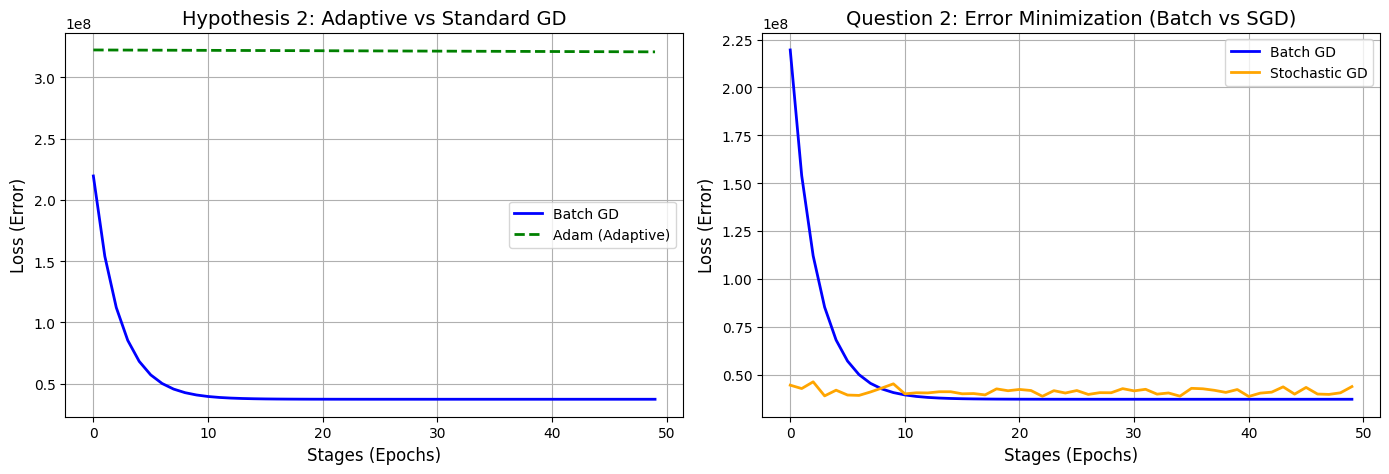

In [5]:
import time

# 1. Standard Batch Gradient Descent (Updated with a Timer!)
def batch_gradient_descent_timed(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    start_time = time.time() # Start the stopwatch
    for epoch in range(epochs):
        prediction = X.dot(weights)
        error = prediction - y
        gradients = (2/m) * X.T.dot(error)
        weights -= learning_rate * gradients
        loss = np.mean((X.dot(weights) - y)**2)
        loss_history.append(loss)
        
    execution_time = time.time() - start_time # Stop the stopwatch
    return loss_history, execution_time

# 2. Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    start_time = time.time()
    for epoch in range(epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            Xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            
            prediction = Xi.dot(weights)
            error = prediction - yi
            gradients = 2 * Xi.T.dot(error)
            weights -= learning_rate * gradients
            
        loss = np.mean((X.dot(weights) - y)**2)
        loss_history.append(loss)
        
    execution_time = time.time() - start_time
    return loss_history, execution_time

# 3. Adaptive Optimizer (Adam - Simplified)
def adam_optimizer(X, y, learning_rate, epochs):
    m = len(y)
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    beta1, beta2, epsilon = 0.9, 0.999, 1e-8
    m_t, v_t = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        prediction = X.dot(weights)
        error = prediction - y
        gradients = (2/m) * X.T.dot(error)
        
        m_t = beta1 * m_t + (1 - beta1) * gradients
        v_t = beta2 * v_t + (1 - beta2) * (gradients**2)
        m_t_hat = m_t / (1 - beta1**epoch)
        v_t_hat = v_t / (1 - beta2**epoch)
        
        weights -= learning_rate * m_t_hat / (np.sqrt(v_t_hat) + epsilon)
        
        loss = np.mean((X.dot(weights) - y)**2)
        loss_history.append(loss)
        
    execution_time = time.time() - start_time
    return loss_history, execution_time

# 4. Run the Race!
epochs = 50
print("Running Batch GD...")
loss_batch, time_batch = batch_gradient_descent_timed(X_train, y_train, learning_rate=0.1, epochs=epochs)

print("Running Stochastic GD...")
loss_sgd, time_sgd = stochastic_gradient_descent(X_train, y_train, learning_rate=0.01, epochs=epochs)

print("Running Adam (Adaptive Optimizer)...")
loss_adam, time_adam = adam_optimizer(X_train, y_train, learning_rate=0.5, epochs=epochs)

# 5. Save metrics to Excel
metrics = pd.DataFrame({
    'Epoch': range(1, epochs + 1),
    'Batch_Loss': loss_batch,
    'SGD_Loss': loss_sgd,
    'Adam_Loss': loss_adam
})
metrics.to_excel('Hypothesis2_Results.xlsx', index=False)
print(f"\n--> Exported 'Hypothesis2_Results.xlsx'")
print(f"Time taken -> Batch: {time_batch:.4f}s | SGD: {time_sgd:.4f}s | Adam: {time_adam:.4f}s")

# 6. Plot the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Proving Hypothesis 2
ax1.plot(range(epochs), loss_batch, label='Batch GD', color='blue', linewidth=2)
ax1.plot(range(epochs), loss_adam, label='Adam (Adaptive)', color='green', linewidth=2, linestyle='--')
ax1.set_title('Hypothesis 2: Adaptive vs Standard GD', fontsize=14)
ax1.set_xlabel('Stages (Epochs)', fontsize=12)
ax1.set_ylabel('Loss (Error)', fontsize=12)
ax1.legend()
ax1.grid(True)

# Plot 2: Answering Question 2
ax2.plot(range(epochs), loss_batch, label='Batch GD', color='blue', linewidth=2)
ax2.plot(range(epochs), loss_sgd, label='Stochastic GD', color='orange', linewidth=2)
ax2.set_title('Question 2: Error Minimization (Batch vs SGD)', fontsize=14)
ax2.set_xlabel('Stages (Epochs)', fontsize=12)
ax2.set_ylabel('Loss (Error)', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()